# 1. Giới thiệu bài toán

Trong dự án này, nhóm thực hiện phân tích chất lượng nước nhằm xác định liệu nước có an toàn để uống hay không.

Chúng tôi sử dụng bộ dữ liệu **Water Potability Dataset** từ Kaggle. Bộ dữ liệu này chứa các chỉ số hóa học và vật lý của nước.

Mục tiêu của bài toán:

- Phân tích các yếu tố ảnh hưởng đến chất lượng nước
- Khai phá các mối quan hệ giữa các chỉ số nước
- Phân cụm các mẫu nước theo đặc điểm hóa học
- Xây dựng mô hình dự đoán nước có an toàn để uống hay không

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/raw/water_potability.csv")

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Data Dictionary

Bảng dưới đây mô tả ý nghĩa của các thuộc tính trong bộ dữ liệu 
Water Potability Dataset. Các thuộc tính này là các chỉ số hóa học 
và vật lý của nước được sử dụng để đánh giá chất lượng nước.

Biến mục tiêu của bài toán là **Potability**:
- 1: nước an toàn để uống
- 0: nước không an toàn

| Thuộc tính | Ý nghĩa |
|-------------|----------|
| pH | Độ axit hoặc kiềm của nước |
| Hardness | Độ cứng của nước |
| Solids | Tổng chất rắn hòa tan |
| Chloramines | Chất khử trùng trong nước |
| Sulfate | Nồng độ sulfate |
| Conductivity | Độ dẫn điện |
| Organic_carbon | Lượng carbon hữu cơ |
| Trihalomethanes | Hợp chất sinh ra khi khử trùng |
| Turbidity | Độ đục của nước |
| Potability | Nước có uống được hay không |

In [8]:
df.shape

(3276, 10)

## 3. Kiểm tra dữ liệu ban đầu

Trong bước này chúng ta kiểm tra:

- Số lượng mẫu trong dataset
- Kiểu dữ liệu của từng thuộc tính
- Các giá trị bị thiếu

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## 4. Kiểm tra giá trị thiếu

Dựa vào kết quả `df.info()`, ta thấy một số thuộc tính có giá trị bị thiếu như:

- pH
- Sulfate
- Trihalomethanes

Các giá trị thiếu này cần được xử lý trong bước tiền xử lý dữ liệu trước khi áp dụng các thuật toán học máy.

In [10]:
df = df.fillna(df.median())

In [11]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Từ kết quả trên có thể thấy một số cột có số lượng giá trị thiếu đáng kể.
Các giá trị này sẽ được xử lý bằng phương pháp điền giá trị trung vị (median) trong bước tiền xử lý.

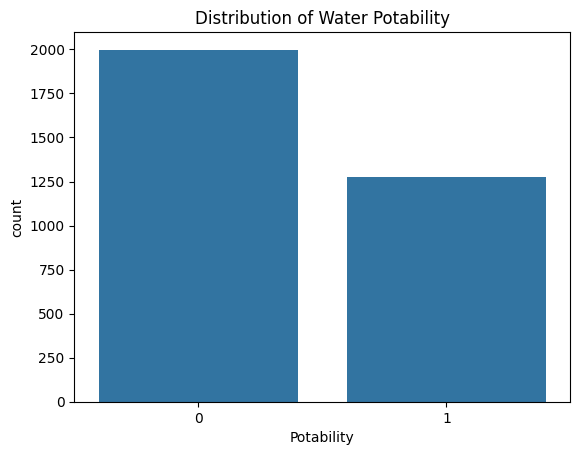

In [12]:
sns.countplot(x="Potability", data=df)
plt.title("Distribution of Water Potability")
plt.show()

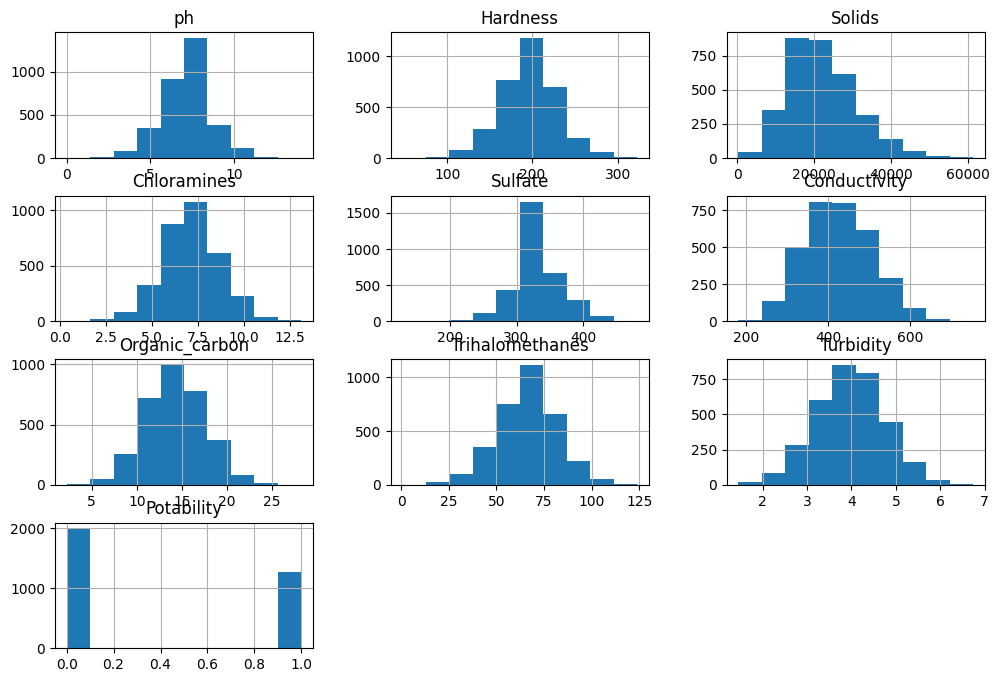

In [13]:
df.hist(figsize=(12,8))
plt.show()

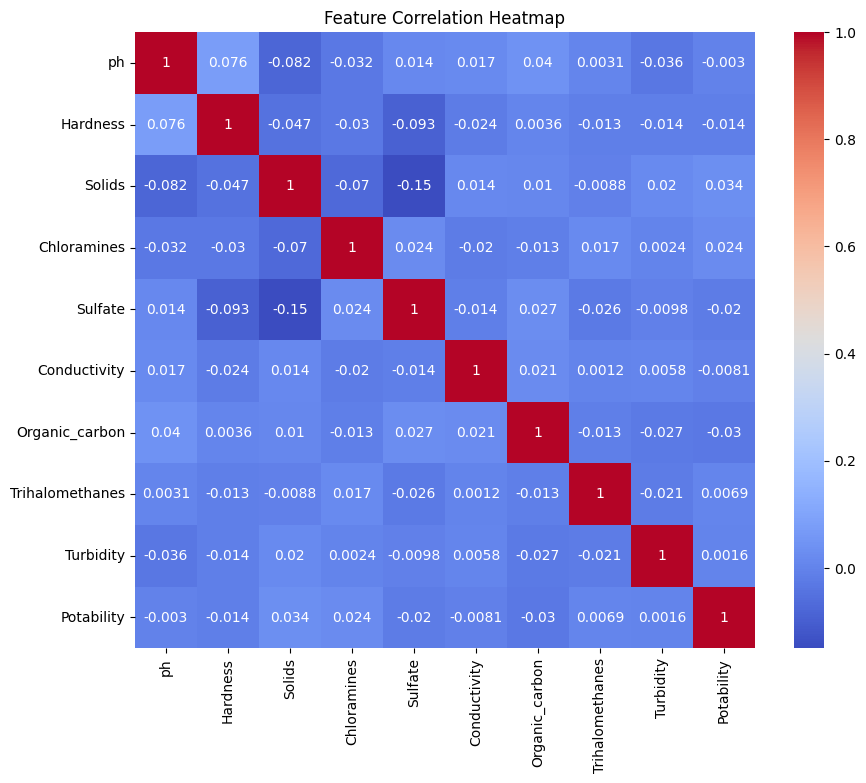

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
df.to_csv("../data/processed/water_clean.csv", index=False)